In [ ]:
# # SwinUNet3D - Segmentation 3D avec Transformers d'une base de donnée de 147 patient d'entrainement avec 50 epochs

# 1. Monte Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install --force-reinstall numpy monai einops timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897

In [ ]:
# 2. Installation des dépendances
import os
import glob
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from monai.utils import first, set_determinism
from monai.data import Dataset, DataLoader, CacheDataset, decollate_batch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, Orientationd,
    ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld,
    RandAffined, AsDiscrete, AsDiscreted, Invertd, SaveImaged
)
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference

import einops
from einops.layers.torch import Rearrange


In [ ]:
# 3. Configuration des chemins
dossier_path = '/content/drive/MyDrive/Nouveau/Lung250M_4B/Lung250M_4B'
# 3 Lister les fichiers dans le dossier
fichiers = os.listdir(dossier_path)
print("Fichiers dans le dossier :", fichiers)

%matplotlib inline
images_train = sorted(glob.glob(os.path.join(dossier_path, "imagesTr", "*.nii.gz")))
labels_train = sorted(glob.glob(os.path.join(dossier_path, "masksTr", "*.nii.gz")))
images_test = sorted(glob.glob(os.path.join(dossier_path, "imagesTs", "*.nii.gz")))
labels_test = sorted(glob.glob(os.path.join(dossier_path, "masksTs", "*.nii.gz")))

print(f'Nombre d\'images train: {len(images_train)}, test: {len(images_test)}')

Fichiers dans le dossier : ['imagesTs', 'imagesTr', 'masksTs', 'masksTr']
Nombre d'images train: 174, test: 30


In [ ]:
# 4. Définition des transformations
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1,
        neg=1,
        num_samples=4,
        image_key="image",
        image_threshold=0,
    ),
    RandAffined(
        keys=['image', 'label'],
        mode=('bilinear', 'nearest'),
        prob=1.0,
        spatial_size=(96, 96, 96),
        rotate_range=(0, 0, np.pi/15),
        scale_range=(0.1, 0.1, 0.1),
    ),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
])

test_transforms = val_transforms

/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [ ]:
# 5. Préparation des données
train_data_dicts = [{"image": img, "label": lbl} for img, lbl in zip(images_train, labels_train)]
test_data_dicts = [{"image": img, "label": lbl} for img, lbl in zip(images_test, labels_test)]

# Division train/val (85%/15%)
train_split = int(0.85 * len(train_data_dicts))
train_files = train_data_dicts[:train_split]
val_files = train_data_dicts[train_split:]

# Création des datasets avec CacheDataset
#train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0)
#val_ds = CacheDataset(data=val_files, transform=val_transforms, cache_rate=1.0)
test_ds = CacheDataset(data=test_data_dicts, transform=test_transforms, cache_rate=1.0)

# DataLoaders
#train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
#val_loader = DataLoader(val_ds, batch_size=1)
test_loader = DataLoader(test_ds, batch_size=1)

Loading dataset: 100%|██████████| 30/30 [01:15<00:00,  2.52s/it]


In [ ]:
# 3. Créer une liste de dictionnaires pour les données de test
test_files = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(images_test, labels_test)
]

# 4. Afficher le nombre de fichiers dans chaque ensemble
print(f"Entraînement : {len(train_files)} fichiers")
print(f"Validation : {len(val_files)} fichiers")
print(f"Test : {len(test_files)} fichiers")

Entraînement : 147 fichiers
Validation : 27 fichiers
Test : 30 fichiers


In [ ]:
# code adapté du projet : https://github.com/1152545264/SwinUnet3D/tree/master
# Les importation
import torch
from torch import nn, einsum
import torch.nn.functional as F # Import pour le padding
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
from typing import Union, List
import numpy as np
from timm.models.layers import trunc_normal_


class CyclicShift3D(nn.Module): # Décale cycliquement les volumes 3D
    def __init__(self, displacement):
        super().__init__()
        # displacement correspond à combien on déplace dans chaque axe
        assert type(displacement) is int or len(displacement) == 3, f'displacement must be 1 or 3 dimension'
        if type(displacement) is int:
            displacement = np.array([displacement, displacement, displacement])
        self.displacement = displacement

    def forward(self, x):
        # torch.roll est utilisé pour décaler cycliquement les élements d'un tenseur.
        # x est l'entrée du modèle c'est à dire le tenseur que sera traité.
        # shifts = décalage sur chaque dimensions et dims=(1,2,3) signifie que les 3 dimension seront traité
        return torch.roll(x, shifts=(self.displacement[0], self.displacement[1], self.displacement[2]), dims=(1, 2, 3))


class Residual3D(nn.Module): #permet d'ajouter une connexion résiduelle dans un réseau 3D
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(x, **kwargs) + x


class PreNorm3D(nn.Module): #pour appliquer une normalisation sur les entrées avant de passer à une transformation
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward3D(nn.Module): # transforme les données en passant par 2 couches avec une activation entre elles
    def __init__(self, dim, hidden_dim, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim), # première couche pour transformer l'entrée de taille dim en hidden_dim
            nn.GELU(), # dans les transformers, GELU donne de meilleur performance que RELU
            nn.Linear(hidden_dim, dim), # deuxième couche pour ramener à la dimension d'origine(dim)
        )
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity() # pour éviter le surapprentissage avec un taux = dropout

    def forward(self, x):
        x = self.net(x)
        x = self.drop(x)
        return x


def create_mask3D(window_size: Union[int, List[int]], displacement: Union[int, List[int]], x_shift: bool, y_shift: bool, z_shift: bool):
    # cette fonction crée un masque 3D pour bloquer l'attention entre certaines positions dans un espace 3D.
    assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'  #vérifie que la taille du cube est un entier et liste de 3 entier
    if type(window_size) is int:
        window_size = np.array([window_size, window_size, window_size])

    assert type(displacement) is int or len(displacement) == 3, f'displacement must be 1 or 3 dimension'
    if type(displacement) is int:
        displacement = np.array([displacement, displacement, displacement])

    assert len(window_size) == len(displacement)
    for i in range(len(window_size)):
        assert 0 < displacement[i] < window_size[i], f'Décalage invalide sur l’axe {i} — les axes sont X(i=0), Y(i=1), Z(i=2)'

    mask = torch.zeros(window_size[0] * window_size[1] * window_size[2], window_size[0] * window_size[1] * window_size[2])  # (wx*wy*wz, wx*wy*wz)
    mask = rearrange(mask, '(x1 y1 z1) (x2 y2 z2) -> x1 y1 z1 x2 y2 z2', x1=window_size[0], y1=window_size[1], x2=window_size[0], y2=window_size[1])

    x_dist, y_dist, z_dist = displacement[0], displacement[1], displacement[2]

    if x_shift:
        #      x1     y1 z1     x2     y2 z2
        mask[-x_dist:, :, :, :-x_dist, :, :] = float('-inf')
        mask[:-x_dist, :, :, -x_dist:, :, :] = float('-inf')

    if y_shift:
        #   x1   y1       z1 x2  y2       z2
        mask[:, -y_dist:, :, :, :-y_dist, :] = float('-inf')
        mask[:, :-y_dist, :, :, -y_dist:, :] = float('-inf')

    if z_shift:
        #   x1  y1  z1       x2 y2  z2
        mask[:, :, -z_dist:, :, :, :-z_dist] = float('-inf')
        mask[:, :, :-z_dist, :, :, -z_dist:] = float('-inf')

    mask = rearrange(mask, 'x1 y1 z1 x2 y2 z2 -> (x1 y1 z1) (x2 y2 z2)')
    return mask


def get_relative_distances(window_size):  # cette fonction calcule les distances entre chaque voxel dans un cube 3D
    assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'
    if type(window_size) is int:
        window_size = np.array([window_size, window_size, window_size])
    indices = torch.tensor( np.array([[x, y, z] for x in range(window_size[0]) for y in range(window_size[1]) for z in range(window_size[2])])) # crée toutes les positions 3D dans la fenêtre

    distances = indices[None, :, :] - indices[:, None, :] #pour chaque paire de positions, calcule la diffèrence [dx,dy,dz]
    # distance:(n,n,3) n =window_size[0]*window_size[1]*window_size[2]
    return distances


class WindowAttention3D(nn.Module):
    #but de la classe : faire de l'attention dans  un cube 3D, fenetré et parfois décalé pour capturer plus de contexte local
    def __init__(self, dim: int, heads: int, head_dim: int, shifted: bool, window_size: Union[int, List[int]], relative_pos_embedding: bool = True):
        super().__init__()

        assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'
        if type(window_size) is int:
            window_size = np.array([window_size, window_size, window_size]) #on crée un cube
        else:
            window_size = np.array(window_size)

        inner_dim = head_dim * heads
        self.heads = heads
        self.scale = head_dim ** -0.5
        self.window_size = window_size
        self.shifted = shifted

        if self.shifted:
            displacement = window_size // 2
            self.cyclic_shift = CyclicShift3D(-displacement)
            self.cyclic_back_shift = CyclicShift3D(displacement)
            self.x_mask = nn.Parameter(create_mask3D(window_size=window_size, displacement=displacement,
                                                     x_shift=True, y_shift=False, z_shift=False), requires_grad=False)
            self.y_mask = nn.Parameter(create_mask3D(window_size=window_size, displacement=displacement,
                                                     x_shift=False, y_shift=True, z_shift=False), requires_grad=False)
            self.z_mask = nn.Parameter(create_mask3D(window_size=window_size, displacement=displacement,
                                                     x_shift=False, y_shift=False, z_shift=True), requires_grad=False)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)  #génération de QKV chacun ayant la même dimension.


        self.softmax = nn.Softmax(dim=-1) #transforme un vecteur de score en probabilités et dim=-1 signifie que la normalisation va se faire sur la dernière dimension de chaque vecteur
        self.to_out = nn.Linear(inner_dim, dim)

    def forward(self, x):
        if self.shifted:
            x = self.cyclic_shift(x)

        b, n_x, n_y, n_z, _, h = *x.shape, self.heads

        qkv = self.to_qkv(x).chunk(3, dim=-1)
        nw_x = n_x // self.window_size[0]
        nw_y = n_y // self.window_size[1]
        nw_z = n_z // self.window_size[2]

        q, k, v = map(
            lambda t: rearrange(t, 'b (nw_x w_x) (nw_y w_y) (nw_z w_z) (h d) -> b h (nw_x nw_y nw_z) (w_x w_y w_z) d',
                                h=h, w_x=self.window_size[0], w_y=self.window_size[1], w_z=self.window_size[2]), qkv)

        dots = einsum('b h w i d, b h w j d -> b h w i j', q, k) * self.scale  # Produit scalaire entre q et k pour obtenir les scores d'attention

        if self.shifted:
            dots = rearrange(dots, 'b h (n_x n_y n_z) i j -> b h n_y n_z n_x i j',
                             n_x=nw_x, n_y=nw_y)
            dots[:, :, :, :, -1] += self.x_mask

            dots = rearrange(dots, 'b h n_y n_z n_x i j -> b h n_x n_z n_y i j')
            dots[:, :, :, :, -1] += self.y_mask

            dots = rearrange(dots, 'b h n_x n_z n_y i j -> b h n_x n_y n_z i j')
            dots[:, :, :, :, -1] += self.z_mask

            dots = rearrange(dots, 'b h n_y n_z n_x i j -> b h (n_x n_y n_z) i j')


        attn = self.softmax(dots)
        out = einsum('b h w i j, b h w j d -> b h w i d', attn, v)
        out = rearrange(out, 'b h (nw_x nw_y nw_z) (w_x w_y w_z) d -> b (nw_x w_x) (nw_y w_y) (nw_z w_z) (h d)',
                        h=h, w_x=self.window_size[0], w_y=self.window_size[1], w_z=self.window_size[2],
                        nw_x=nw_x, nw_y=nw_y, nw_z=nw_z)
        out = self.to_out(out)

        if self.shifted:
            out = self.cyclic_back_shift(out)
        return out


class SwinBlock3D(nn.Module):  #capture les dépendances à longue distance dans les images 3D via une attention multi-têtes localisée
    def __init__(self, dim, heads, head_dim, mlp_dim, shifted, window_size: Union[int, List[int]],
                 relative_pos_embedding: bool = True, dropout: float = 0.0):
        super().__init__()
        self.attention_block = Residual3D(PreNorm3D(dim, WindowAttention3D(dim=dim,
                                                                           heads=heads,
                                                                           head_dim=head_dim,
                                                                           shifted=shifted,
                                                                           window_size=window_size,
                                                                           relative_pos_embedding=relative_pos_embedding)))
        self.mlp_block = Residual3D(PreNorm3D(dim, FeedForward3D(dim=dim, hidden_dim=mlp_dim, dropout=dropout)))

    def forward(self, x):
        x = self.attention_block(x)
        x = self.mlp_block(x)
        return x


class Norm(nn.Module): #normalisation sur les features
    def __init__(self, dim, channel_first: bool = True):
        super(Norm, self).__init__()
        if channel_first:
            self.net = nn.Sequential(
                Rearrange('b c h w d -> b h w d c'),
                nn.LayerNorm(dim),
                Rearrange('b h w d c -> b c h w d')
            )

            # self.net = nn.InstanceNorm3d(dim, eps=1e-5, momentum=0.1, affine=False)
        else:
            self.net = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.net(x)
        return x


class PatchMerging3D(nn.Module): # faire un downsampling 3D (réduction de taille spatiale + profondeur) tout en augmentant la richesse des features
    #c'est un peu comme fusionner plusieurs petits cubes(patchs) en un plus gros, pour capturer plus de contexte
    def __init__(self, in_dim, out_dim, downscaling_factor):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_dim, out_dim, kernel_size=downscaling_factor, stride=downscaling_factor),
            Norm(dim=out_dim),
        )

    def forward(self, x):
        # x: B, C, H, W, D
        x = self.net(x)
        return x  # B,  H //down_scaling, W//down_scaling, D//down_scaling, out_dim


class PatchExpanding3D(nn.Module): #pour créer une version plus grande du volume 3D, avec une résolution plus fine (X,Y,Z)
    def __init__(self, in_dim, out_dim, up_scaling_factor):
        super(PatchExpanding3D, self).__init__()

        stride = up_scaling_factor
        kernel_size = up_scaling_factor
        padding = (kernel_size - stride) // 2
        self.net = nn.Sequential(
            nn.ConvTranspose3d(in_dim, out_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            Norm(out_dim),
        )

    def forward(self, x):
        '''X: B,C,X,Y,Z'''
        x = self.net(x)
        return x


class FinalExpand3D(nn.Module):  # sert à agrandir un volume 3D (upscaling) et à générer une sortie finale (ex: classes) avec normalisation et activation.
    def __init__(self, in_dim, out_dim, up_scaling_factor):
        super(FinalExpand3D, self).__init__()

        stride = up_scaling_factor
        kernel_size = up_scaling_factor
        padding = (kernel_size - stride) // 2
        self.net = nn.Sequential(
            nn.ConvTranspose3d(in_dim, out_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            Norm(out_dim),
            nn.PReLU()
        )

    def forward(self, x):
        '''X: B,C,H,W,D'''
        x = self.net(x)
        return x


class ConvBlock(nn.Module):  # bloc de convolution avec 2 convolution successives sur les données d'entrée
    def __init__(self, in_ch, out_ch):
        super(ConvBlock, self).__init__()
        groups = min(in_ch, out_ch)
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, groups=groups),
            Norm(dim=out_ch),
            nn.PReLU(),

            nn.Conv3d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, groups=groups),
            Norm(dim=out_ch),
            nn.PReLU(),
        )

    def forward(self, x):
        x2 = x.clone()
        x = self.net(x) * x2
        return x


class Encoder(nn.Module):
    def __init__(self, in_dims, hidden_dimension, layers, downscaling_factor, num_heads, head_dim,
                 window_size: Union[int, List[int]], relative_pos_embedding: bool = True, dropout: float = 0.0):
        super().__init__()
        assert layers % 2 == 0, 'Stage layers need to be divisible by 2 for regular and shifted block.'

        self.patch_partition = PatchMerging3D(in_dim=in_dims, out_dim=hidden_dimension,downscaling_factor=downscaling_factor)
        self.conv_block = ConvBlock(in_ch=hidden_dimension, out_ch=hidden_dimension)

        self.re1 = Rearrange('b c h w d -> b h w d c')
        self.swin_layers = nn.ModuleList([])
        for _ in range(layers // 2):
            self.swin_layers.append(nn.ModuleList([
                SwinBlock3D(dim=hidden_dimension, heads=num_heads, head_dim=head_dim, mlp_dim=hidden_dimension * 4,
                            shifted=False, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
                SwinBlock3D(dim=hidden_dimension, heads=num_heads, head_dim=head_dim, mlp_dim=hidden_dimension * 4,
                            shifted=True, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
            ]))
        self.re2 = Rearrange('b  h w d c -> b c h w d')

    def forward(self, x):
        x = self.patch_partition(x)
        x2 = self.conv_block(x)  # Le bloc convolutionnel apprend des dépendances à courte portée.

        x = self.re1(x)
        for regular_block, shifted_block in self.swin_layers:  # Le bloc swin_layers apprend des dépendances à longue portée
            x = regular_block(x)
            x = shifted_block(x)
        x = self.re2(x)

        x = x + x2  # Fusionner les informations de dépendance à courte et longue portée
        return x


class Decoder(nn.Module):
    def __init__(self, in_dims, out_dims, layers, up_scaling_factor, num_heads, head_dim, window_size: Union[int, List[int]], relative_pos_embedding, dropout: float = 0.0):
        super().__init__()
        assert layers % 2 == 0, 'Stage layers need to be divisible by 2 for regular and shifted block.'

        self.patch_expand = PatchExpanding3D(in_dim=in_dims, out_dim=out_dims, up_scaling_factor=up_scaling_factor)

        self.conv_block = ConvBlock(in_ch=out_dims, out_ch=out_dims)
        self.re1 = Rearrange('b c h w d -> b h w d c')
        self.swin_layers = nn.ModuleList([])
        for _ in range(layers // 2):
            self.swin_layers.append(nn.ModuleList([
                SwinBlock3D(dim=out_dims, heads=num_heads, head_dim=head_dim, mlp_dim=out_dims * 4,
                            shifted=False, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
                SwinBlock3D(dim=out_dims, heads=num_heads, head_dim=head_dim, mlp_dim=out_dims * 4,
                            shifted=True, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
            ]))
        self.re2 = Rearrange('b h w d c -> b c h w d')

    def forward(self, x):
        x = self.patch_expand(x)

        x2 = self.conv_block(x)

        x = self.re1(x)
        for regular_block, shifted_block in self.swin_layers:
            x = regular_block(x)
            x = shifted_block(x)
        x = self.re2(x)

        x = x + x2
        return x


class Converge(nn.Module):
    def __init__(self, dim: int):
        '''
        stack : La méthode de fusion est réalisée par empilement + transformation linéaire.
        add : Les connexions résiduelles sont réalisées par addition directe.
        '''
        super(Converge, self).__init__()
        self.norm = Norm(dim=dim)

    def forward(self, x, enc_x):
        '''
         x: B,C,X,Y,Z
        enc_x:B,C,X,Y,Z
        '''
        assert x.shape == enc_x.shape
        x = x + enc_x
        x = self.norm(x)
        return x


class SwinUnet3D(nn.Module):
    def __init__(self, *, hidden_dim, layers, heads, in_channel=1, num_classes=2, head_dim=32,
                 window_size: Union[int, List[int]] = 7, downscaling_factors=(4, 2, 2, 2),
                 relative_pos_embedding=True, dropout: float = 0.0, skip_style='stack',
                 stl_channels: int = 32):  # second_to_last_channels
        super().__init__()

        self.dsf = downscaling_factors

        self.window_size = window_size

        self.enc12 = Encoder(in_dims=in_channel, hidden_dimension=hidden_dim, layers=layers[0],
                             downscaling_factor=downscaling_factors[0], num_heads=heads[0],
                             head_dim=head_dim, window_size=window_size, dropout=dropout,
                             relative_pos_embedding=relative_pos_embedding)
        self.enc3 = Encoder(in_dims=hidden_dim, hidden_dimension=hidden_dim * 2,
                            layers=layers[1],
                            downscaling_factor=downscaling_factors[1], num_heads=heads[1],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)
        self.enc4 = Encoder(in_dims=hidden_dim * 2, hidden_dimension=hidden_dim * 4,
                            layers=layers[2],
                            downscaling_factor=downscaling_factors[2], num_heads=heads[2],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)
        self.enc5 = Encoder(in_dims=hidden_dim * 4, hidden_dimension=hidden_dim * 8,
                            layers=layers[3],
                            downscaling_factor=downscaling_factors[3], num_heads=heads[3],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)

        self.dec4 = Decoder(in_dims=hidden_dim * 8, out_dims=hidden_dim * 4,
                            layers=layers[2],
                            up_scaling_factor=downscaling_factors[3], num_heads=heads[2],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)

        self.dec3 = Decoder(in_dims=hidden_dim * 4, out_dims=hidden_dim * 2,
                            layers=layers[1],
                            up_scaling_factor=downscaling_factors[2], num_heads=heads[1],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)

        self.dec12 = Decoder(in_dims=hidden_dim * 2, out_dims=hidden_dim,
                             layers=layers[0],
                             up_scaling_factor=downscaling_factors[1], num_heads=heads[0],
                             head_dim=head_dim, window_size=window_size, dropout=dropout,
                             relative_pos_embedding=relative_pos_embedding)

        self.converge4 = Converge(hidden_dim * 4)
        self.converge3 = Converge(hidden_dim * 2)
        self.converge12 = Converge(hidden_dim)

        self.final = FinalExpand3D(in_dim=hidden_dim, out_dim=stl_channels,
                                   up_scaling_factor=downscaling_factors[0])
        self.out = nn.Sequential(
            # nn.Linear(stl_channels, num_classes),
            # Rearrange('b h w d c -> b c h w d'),
            nn.Conv3d(stl_channels, num_classes, kernel_size=1)
        )
        # Initialisation des paramètres
        self.init_weight()

    def forward(self, img):
        window_size = self.window_size
        assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'
        if type(window_size) is int:
            window_size = np.array([window_size, window_size, window_size])

        # Get input shape
        _, _, x_s, y_s, z_s = img.shape
        x_ws, y_ws, z_ws = window_size

        # Calculate padding to make dimensions divisible by window_size * 32
        x_pad = (x_ws * 32) - (x_s % (x_ws * 32)) if x_s % (x_ws * 32) != 0 else 0
        y_pad = (y_ws * 32) - (y_s % (y_ws * 32)) if y_s % (y_ws * 32) != 0 else 0
        z_pad = (z_ws * 32) - (z_s % (z_ws * 32)) if z_s % (z_ws * 32) != 0 else 0

        # Pad the input image
        img = F.pad(img, (0, z_pad, 0, y_pad, 0, x_pad))

        down12_1 = self.enc12(img)  # (B,C, X//4, Y//4, Z//4)
        down3 = self.enc3(down12_1)  # (B, 2C,X//8, Y//8, Z//8)
        down4 = self.enc4(down3)  # (B, 4C,X//16, Y//16, Z//16)
        features = self.enc5(down4)  # (B, 8C,X//32, Y//32, Z//32)


        up4 = self.dec4(features)  # (B, 8C, X//16, Y//16, Z//16 )
        up4 = self.converge4(up4, down4)  # (B, 4C, X//16, Y//16, Z//16)

        up3 = self.dec3(up4)  # ((B, 2C,X//8, Y//8, Z//8)
        up3 = self.converge3(up3, down3)  # (B,2C, X//8, Y//8)

        up12 = self.dec12(up3)  # (B,C, X//4, Y//4, Z// 4)
        up12 = self.converge12(up12, down12_1)  # (B,C, X//4, Y//4, Z//4)

        out = self.final(up12)  # (B,num_classes, X, Y, Z)
        out = self.out(out)

        # Remove padding from the output before returning
        out = out[:, :, :x_s, :y_s, :z_s]
        return out

    def init_weight(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv3d, nn.ConvTranspose3d)):
                trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            if isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)



def swinUnet_t_3D(hidden_dim=96, layers=(2, 2, 6, 4), heads=(3, 6, 9, 12), num_classes: int = 2, **kwargs):
    return SwinUnet3D(hidden_dim=hidden_dim, layers=layers, heads=heads, num_classes=num_classes, **kwargs)

/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
# 6. Initialisation
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = swinUnet_t_3D( # Use the defined swinUnet_t_3D function instead
    hidden_dim=48,  # Réduit pour Colab (original=96)
    layers=[2, 2, 6, 2],
    heads=[3, 6, 12, 24],
    in_channel=1,
    num_classes=2,
    window_size=3
).to(device)

loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [ ]:
from monai.inferers import sliding_window_inference

# Define hyperparameters
max_epochs = 50
val_interval = 2
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

# Define post-processing transforms
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=2)])
post_label = Compose([AsDiscrete(to_onehot=2)])

# Training loop
for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)

    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            val_sample = next(iter(val_loader))
            print("Label shape :", val_sample["label"].shape)
            print("Label unique values :", torch.unique(val_sample["label"]))
            print("Image shape :", val_sample["image"].shape)
            for val_data in val_loader:
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device),
                val_outputs = sliding_window_inference(val_inputs, (224, 224, 224), 1, model)

                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]

                # compute metric for current iteration
                dice_metric(y_pred=val_outputs, y=val_labels)

            # aggregate the final mean dice result
            metric = dice_metric.aggregate().item()

            # reset the status for next validation round
            dice_metric.reset()

            metric_values.append(metric)
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_metric_model.pth")
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch}"
            )

from google.colab import files
files.download('best_metric_model.pth')



Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
37/147, train_loss: 0.0397
38/147, train_loss: 0.0204
39/147, train_loss: 0.0416
40/147, train_loss: 0.0308
41/147, train_loss: 0.0269
42/147, train_loss: 0.0309
43/147, train_loss: 0.0218
44/147, train_loss: 0.0328
45/147, train_loss: 0.0276
46/147, train_loss: 0.0375
47/147, train_loss: 0.1442
48/147, train_loss: 0.0265
49/147, train_loss: 0.0482
50/147, train_loss: 0.0683
51/147, train_loss: 0.0335
52/147, train_loss: 0.0811
53/147, train_loss: 0.0918
54/147, train_loss: 0.1337
55/147, train_loss: 0.0387
56/147, train_loss: 0.0540
57/147, train_loss: 0.0670
58/147, train_loss: 0.0411
59/147, train_loss: 0.1179
60/147, train_loss: 0.1839
61/147, train_loss: 0.0712
62/147, train_loss: 0.0404
63/147, train_loss: 0.0464
64/147, train_loss: 0.0695
65/147, train_loss: 0.0733
66/147, train_loss: 0.0655
67/147, train_loss: 0.0515
68/147, train_loss: 0.0291
69/147, train_loss: 0.0330
70/147, train_loss: 0.0210
71/1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

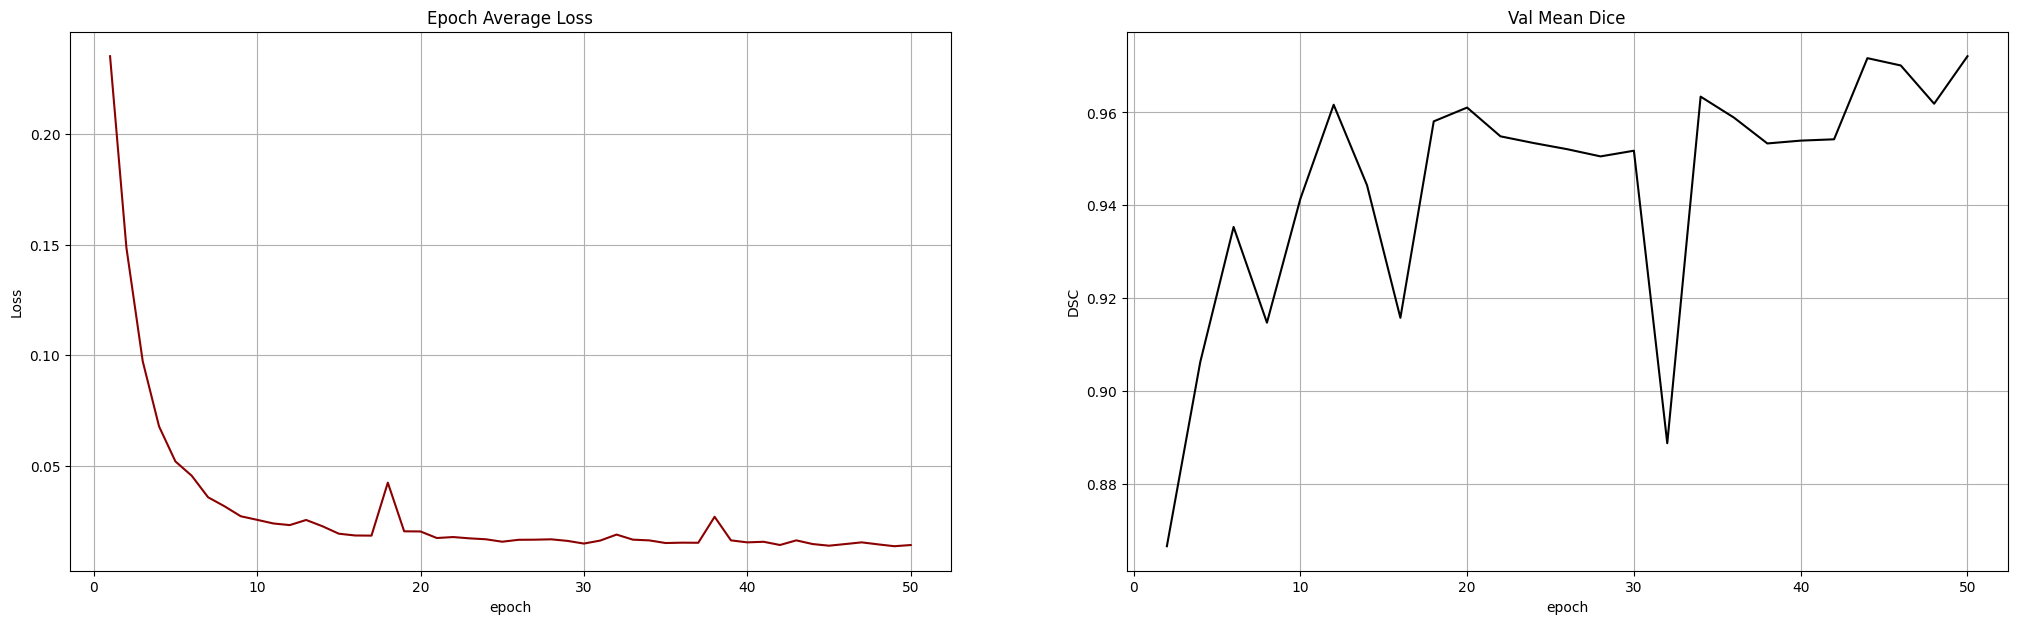

In [ ]:
plt.figure("train", (25,7))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.ylabel("Loss")
plt.xlabel("epoch")
plt.plot(x, y, color='darkred')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.ylabel("DSC")
plt.xlabel("epoch")
plt.grid(True)
plt.plot(x, y, color='black')
plt.show()

In [ ]:
test_ds = Dataset(data=test_files, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=1)

post_transforms = Compose([
    Invertd(
        keys="pred",
        transform=val_transforms,
        orig_keys="image",
        meta_keys="pred_meta_dict",
        orig_meta_keys="image_meta_dict",
        meta_key_postfix="meta_dict",
        nearest_interp=False,
        to_tensor=True,
    ),
    AsDiscreted(keys="pred", argmax=True, to_onehot=2),
    SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
])

In [ ]:
"""
import torch
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged, AsDiscrete
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch

# Charger le modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = swinUnet_t_3D(hidden_dim=48, layers=[2, 2, 6, 2], heads=[3, 6, 12, 24], in_channel=1, num_classes=2, window_size=3).to(device)
model.load_state_dict(torch.load("best_metric_model.pth", map_location=device))
model.eval()

# Transformations pour le post-traitement
post_pred = AsDiscrete(argmax=True, to_onehot=2)

# Parcourir les données de test
for i, test_data in enumerate(test_loader):
    print(f"Traitement de l'image de test n°{i + 1}")  # Afficher le numéro de l'image
    test_inputs, test_labels = test_data["image"].to(device), test_data["label"].to(device)

    # Inférence avec sliding window
    with torch.no_grad():
        test_outputs = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)

    # Post-traitement des sorties
    test_outputs = [post_pred(i) for i in decollate_batch(test_outputs)]

    # Convertir les masques en numpy arrays
    predicted_mask = test_outputs[0][1].cpu().numpy()  # Classe 1 (poumon)

    # Extraire la classe "poumon" (index 1) directement
    reference_mask = (test_labels[0] == 1).cpu().numpy().astype(np.uint8)

    # Compter le nombre de voxels
    num_voxels_predicted = np.sum(predicted_mask)
    num_voxels_reference = np.sum(reference_mask)

    print(f"Nombre de voxels dans le masque prédit: {num_voxels_predicted}")
    print(f"Nombre de voxels dans le masque de référence: {num_voxels_reference}")

    # Calculer la différence
    diff = num_voxels_predicted - num_voxels_reference
    print(f"Différence de voxels: {diff}")

  """

Traitement de l'image de test n°1
Nombre de voxels dans le masque prédit: 1734504.0
Nombre de voxels dans le masque de référence: 1716484
Différence de voxels: 18020.0
Traitement de l'image de test n°2
Nombre de voxels dans le masque prédit: 971739.0
Nombre de voxels dans le masque de référence: 959835
Différence de voxels: 11904.0
Traitement de l'image de test n°3
Nombre de voxels dans le masque prédit: 1752716.0
Nombre de voxels dans le masque de référence: 1744650
Différence de voxels: 8066.0
Traitement de l'image de test n°4
Nombre de voxels dans le masque prédit: 799417.0
Nombre de voxels dans le masque de référence: 783962
Différence de voxels: 15455.0
Traitement de l'image de test n°5
Nombre de voxels dans le masque prédit: 1386574.0
Nombre de voxels dans le masque de référence: 1373493
Différence de voxels: 13081.0
Traitement de l'image de test n°6
Nombre de voxels dans le masque prédit: 796541.0
Nombre de voxels dans le masque de référence: 786201
Différence de voxels: 10340.0

Traitement de l'image de test n°1
Nombre de voxels dans le masque prédit: 1734504.0
Nombre de voxels dans le masque de référence: 1716484
Différence de voxels: 18020.0
TP: 1688769, FP: 45735, FN: 27715, TN: 3933501
Traitement de l'image de test n°2
Nombre de voxels dans le masque prédit: 971739.0
Nombre de voxels dans le masque de référence: 959835
Différence de voxels: 11904.0
TP: 936419, FP: 35320, FN: 23416, TN: 4700565
Traitement de l'image de test n°3
Nombre de voxels dans le masque prédit: 1752716.0
Nombre de voxels dans le masque de référence: 1744650
Différence de voxels: 8066.0
TP: 1719987, FP: 32729, FN: 24663, TN: 4499027
Traitement de l'image de test n°4
Nombre de voxels dans le masque prédit: 799417.0
Nombre de voxels dans le masque de référence: 783962
Différence de voxels: 15455.0
TP: 769366, FP: 30051, FN: 14596, TN: 5462393
Traitement de l'image de test n°5
Nombre de voxels dans le masque prédit: 1386574.0
Nombre de voxels dans le masque de référence: 1373493
Différenc

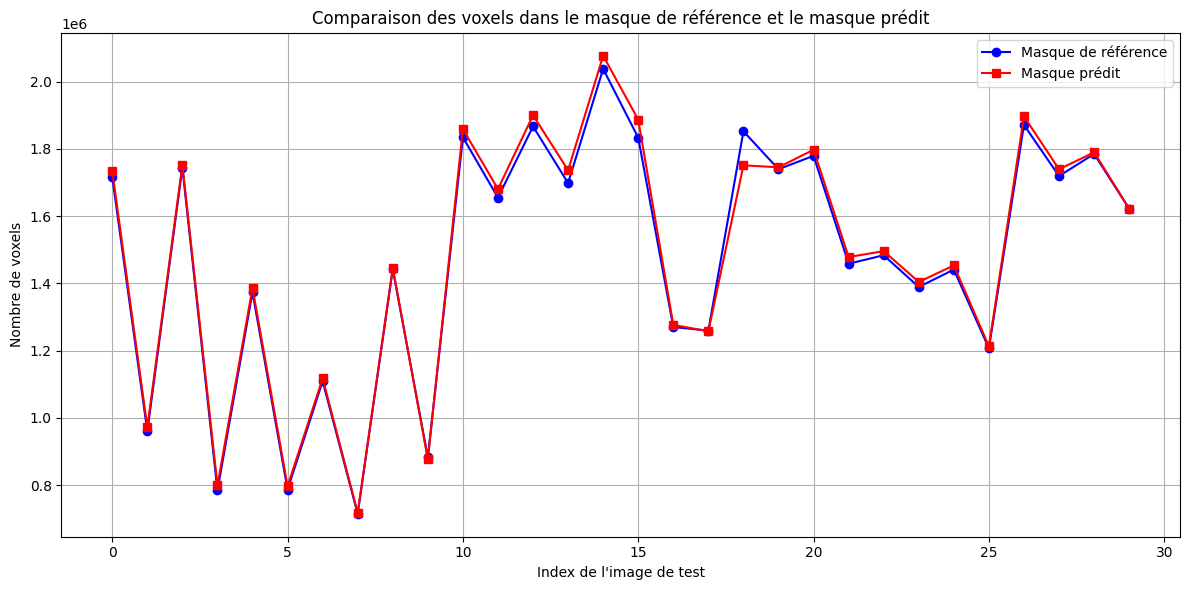

In [ ]:
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

from monai.transforms import LoadImaged, AsDiscrete
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch

# Charger le modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = swinUnet_t_3D(hidden_dim=48, layers=[2, 2, 6, 2], heads=[3, 6, 12, 24], in_channel=1, num_classes=2, window_size=3).to(device)
model.load_state_dict(torch.load("best_metric_model.pth", map_location=device))
model.eval()

# Transformations pour le post-traitement
post_pred = AsDiscrete(argmax=True, to_onehot=2)

# Listes pour stocker les résultats
reference_voxels = []
predicted_voxels = []
TP_list = []
FP_list = []
FN_list = []
TN_list = []

# Parcourir les données de test
for i, test_data in enumerate(test_loader):
    print(f"Traitement de l'image de test n°{i + 1}")
    test_inputs, test_labels = test_data["image"].to(device), test_data["label"].to(device)

    # Inférence avec sliding window
    with torch.no_grad():
        test_outputs = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)

    # Post-traitement des sorties
    test_outputs = [post_pred(i) for i in decollate_batch(test_outputs)]

    # Convertir les masques en numpy arrays et supprimer les dimensions supplémentaires
    predicted_mask = test_outputs[0][1].cpu().numpy()
    predicted_mask = np.squeeze(predicted_mask)  # Supprimer les dimensions supplémentaires
    reference_mask = (test_labels[0] == 1).cpu().numpy().astype(np.uint8)
    reference_mask = np.squeeze(reference_mask)  # Supprimer les dimensions supplémentaires

    # Redimensionner le masque prédit à la taille du masque de référence
    if predicted_mask.shape != reference_mask.shape:
        zoom_factors = np.array(reference_mask.shape) / np.array(predicted_mask.shape)
        predicted_mask = scipy.ndimage.zoom(predicted_mask, zoom_factors, order=0)
        predicted_mask = (predicted_mask > 0.5).astype(np.int32)  # Re-binariser après redimensionnement

    # Calculer le nombre de voxels
    num_voxels_predicted = np.sum(predicted_mask)
    num_voxels_reference = np.sum(reference_mask)

    reference_voxels.append(num_voxels_reference)
    predicted_voxels.append(num_voxels_predicted)

    # Calcul des métriques (après le redimensionnement)
    TP = np.logical_and(predicted_mask == 1, reference_mask == 1).sum()
    FP = np.logical_and(predicted_mask == 1, reference_mask == 0).sum()
    FN = np.logical_and(predicted_mask == 0, reference_mask == 1).sum()
    TN = np.logical_and(predicted_mask == 0, reference_mask == 0).sum()

    TP_list.append(TP)
    FP_list.append(FP)
    FN_list.append(FN)
    TN_list.append(TN)

    print(f"Nombre de voxels dans le masque prédit: {num_voxels_predicted}")
    print(f"Nombre de voxels dans le masque de référence: {num_voxels_reference}")
    print(f"Différence de voxels: {num_voxels_predicted - num_voxels_reference}")
    print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")

# Calcul des métriques globales
total_TP = np.sum(TP_list)
total_FP = np.sum(FP_list)
total_FN = np.sum(FN_list)
total_TN = np.sum(TN_list)

precision = total_TP / (total_TP + total_FP + 1e-8)
recall = total_TP / (total_TP + total_FN + 1e-8)

print("\n--- Résultats globaux ---")
print(f"Précision : {precision:.4f} | Rappel : {recall:.4f}")

# Affichage du graphe comparatif
plt.figure(figsize=(12, 6))
x = np.arange(len(test_files))

plt.plot(x, reference_voxels, label="Masque de référence", marker='o', color='blue')
plt.plot(x, predicted_voxels, label="Masque prédit", marker='s', color='red')

plt.xlabel("Index de l'image de test")
plt.ylabel("Nombre de voxels")
plt.title("Comparaison des voxels dans le masque de référence et le masque prédit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-04-29 15:13:07,145 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


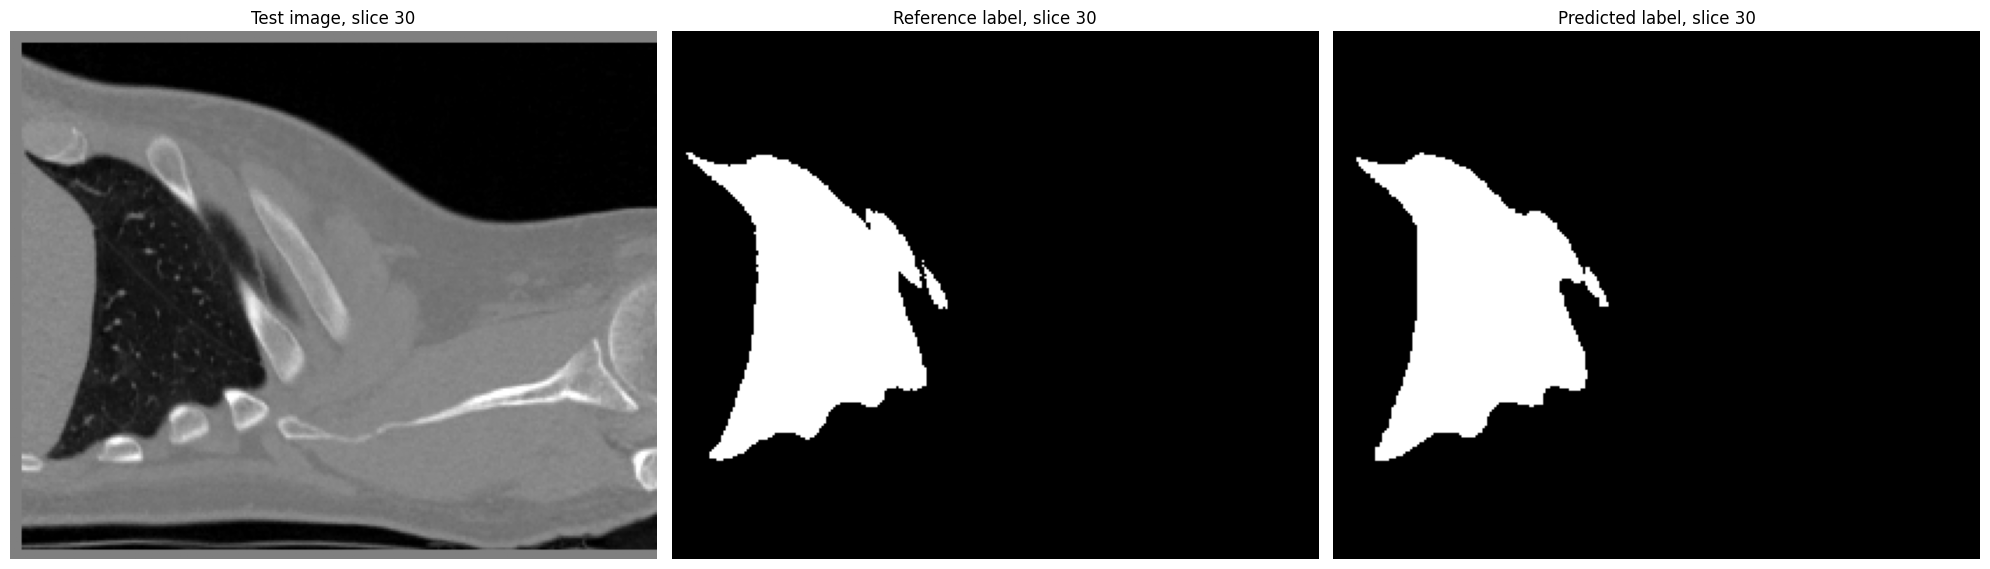

In [ ]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 30
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-04-29 15:13:26,139 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


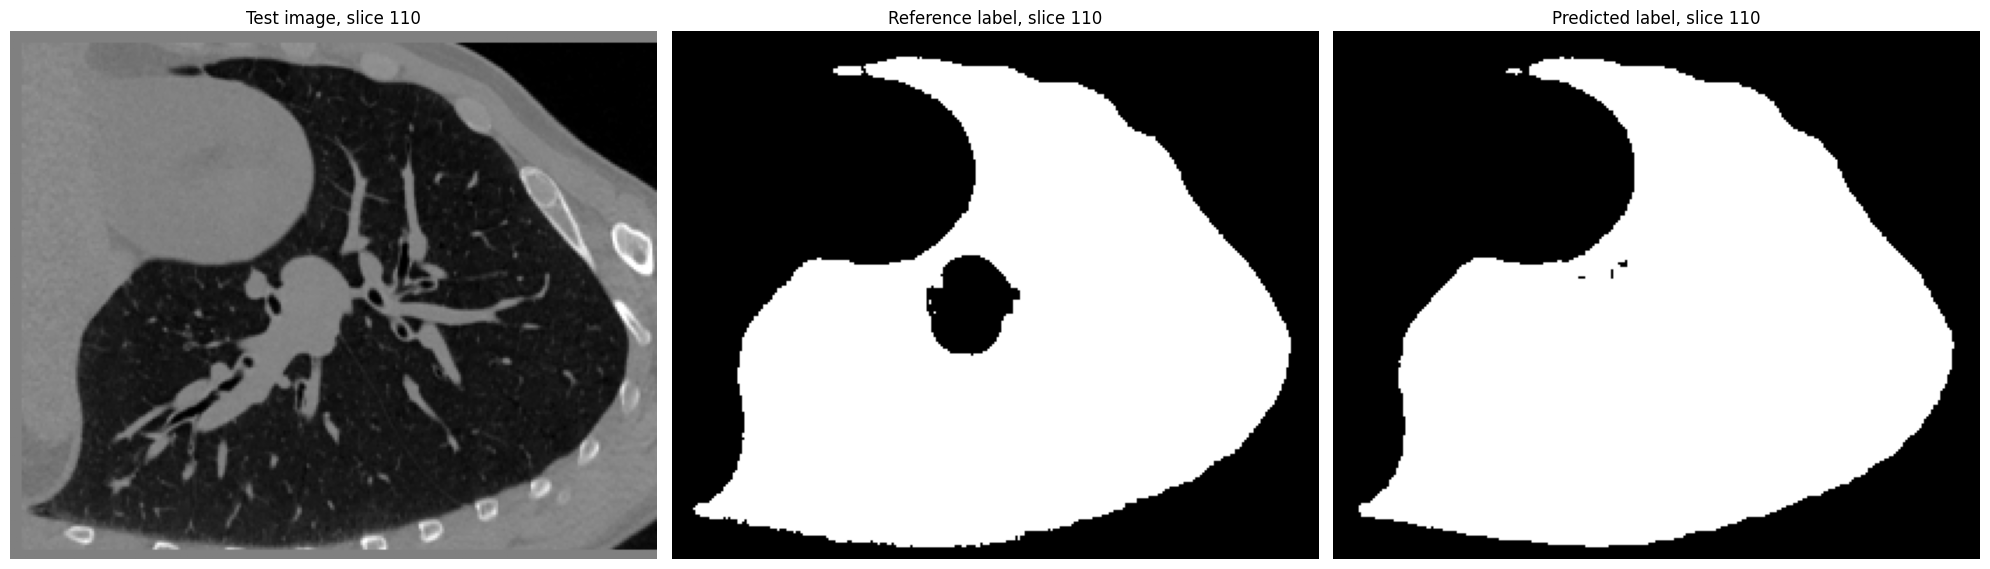

In [ ]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 110
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()

Original image shape: torch.Size([308, 226, 277])
Original label shape: torch.Size([308, 226, 277])
2025-04-29 15:13:41,634 INFO image_writer.py:197 - writing: out/case_054_1/case_054_1_seg.nii.gz


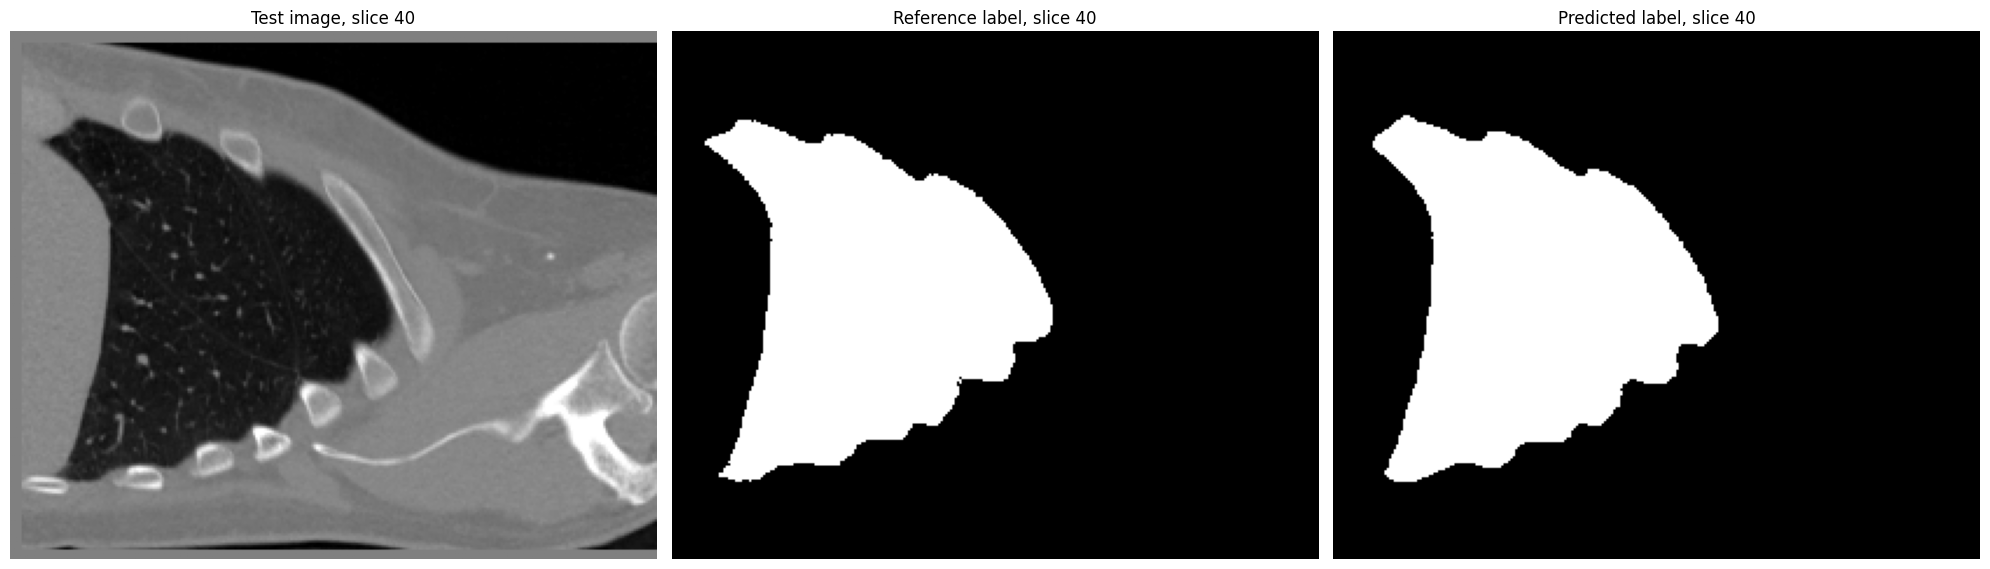

In [ ]:
import torch
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from monai.transforms import LoadImaged
from monai.inferers import sliding_window_inference
from monai.handlers.utils import from_engine
from monai.data import decollate_batch

# Charger les images avec nibabel
image_path = test_files[0]['image']
label_path = test_files[0]['label']

image_data = nib.load(image_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# Convertir en tensors PyTorch
original_image = torch.from_numpy(image_data).float()
original_label = torch.from_numpy(label_data).float()

# Vérifier la forme des images
print("Original image shape:", original_image.shape)
print("Original label shape:", original_label.shape)

# Choisir une coupe 2D
slice_idx = 40
image_slice_2d = original_image[slice_idx].detach().cpu().numpy()
label_slice_2d = original_label[slice_idx].detach().cpu().numpy()

# Charger le modèle
model.load_state_dict(torch.load("best_metric_model.pth", map_location="cpu"))
model.eval()

# Exécuter l'inférence
with torch.no_grad():
    for test_data in test_loader:
        test_inputs = test_data["image"].to(device)
        test_data["pred"] = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)
        test_data = [post_transforms(i) for i in decollate_batch(test_data)]
        test_output = from_engine(["pred"])(test_data)
        break  # Un seul batch

# Extraire la prédiction pour la classe "poumon" (index 1)
predicted_mask = torch.argmax(test_output[0], dim=0)  # Réduction sur l'axe des classes
predicted_slice = predicted_mask[slice_idx].detach().cpu().numpy()

# Afficher les résultats
plt.figure(figsize=(20, 7))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(image_slice_2d, cmap="gray", vmin=-1000, vmax=1000)
plt.title(f'Test image, slice {slice_idx}')
plt.axis('off')

# Label de référence
plt.subplot(1, 3, 2)
plt.imshow(label_slice_2d, cmap="gray")
plt.title(f'Reference label, slice {slice_idx}')
plt.axis('off')

# Prédiction
plt.subplot(1, 3, 3)
plt.imshow(predicted_slice, cmap="gray")
plt.title(f'Predicted label, slice {slice_idx}')
plt.axis('off')

plt.tight_layout()
plt.show()